In [1]:
import torch
import torchvision
from torch import nn
import os
import matplotlib.pyplot as plt
from torchvision import transforms
from torchinfo import summary
import random
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
%matplotlib inline

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
train_dir = 'archive/images/train'
val_dir = 'archive/images/validation'

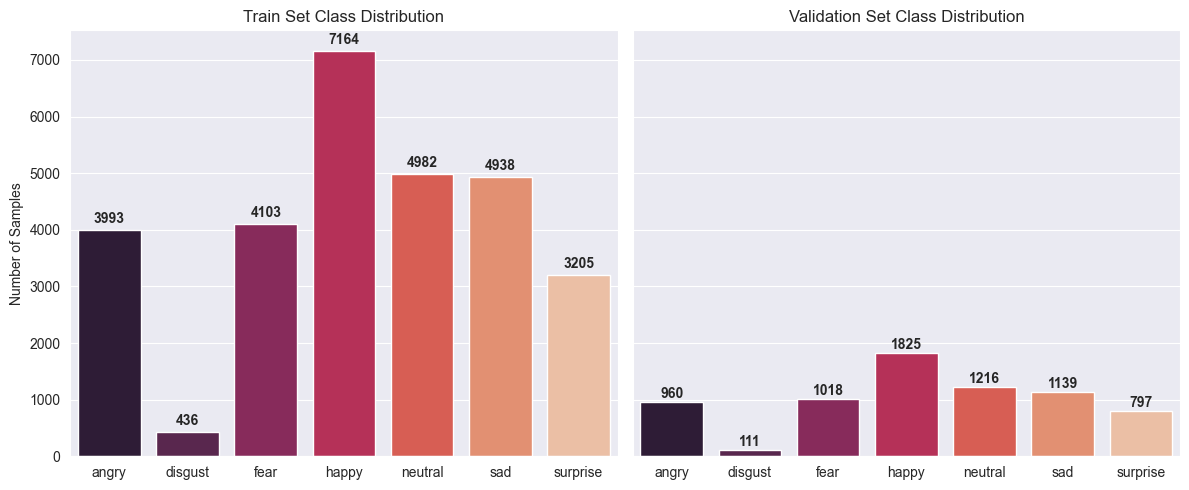

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import os

sns.set_style("darkgrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Train set class distribution
train_class_samples = {label: len(os.listdir(os.path.join(train_dir, label))) 
                      for label in os.listdir(train_dir)}
train_class_samples_df = pd.DataFrame({
    'label': train_class_samples.keys(), 
    'samples': train_class_samples.values()
})

hue_order = train_class_samples.keys()

sns.barplot(data=train_class_samples_df, x='label', y='samples', 
           palette='rocket', hue='label', ax=axes[0])
axes[0].set_title('Train Set Class Distribution')
axes[0].set_xlabel(None)
axes[0].set_ylabel('Number of Samples')

for i, v in enumerate(train_class_samples_df['samples']):
    axes[0].text(i, v + 0.01 * max(train_class_samples_df['samples']), 
                str(v), ha='center', va='bottom', fontweight='bold')

# Validation set class distribution
val_class_samples = {label: len(os.listdir(os.path.join(val_dir, label))) 
                    for label in os.listdir(val_dir)}
val_class_samples_df = pd.DataFrame({
    'label': val_class_samples.keys(), 
    'samples': val_class_samples.values()
})

sns.barplot(data=val_class_samples_df, x='label', y='samples', 
           palette='rocket', hue='label', ax=axes[1])
axes[1].set_title('Validation Set Class Distribution')
axes[1].set_xlabel(None)

# Add text annotations for validation set
for i, v in enumerate(val_class_samples_df['samples']):
    axes[1].text(i, v + 0.01 * max(val_class_samples_df['samples']), 
                str(v), ha='center', va='bottom', fontweight='bold')

# Adjust layout and show
plt.tight_layout()
plt.show()


### Dataset Imbalance

The dataset exhibits a significant class imbalance. For example, in the training set, the number of images per class varies widely: the 'happy' class contains 7,164 images, while the 'disgust' class has only 436 images. This imbalance is also present in the validation set, where 'happy' has 1,825 images and 'disgust' only 111. Such disparities can lead to biased model performance, where the model may perform better on classes with more samples and worse on underrepresented classes. Addressing this imbalance is important for building a robust and fair classifier.

In [6]:
from torchvision import datasets, transforms
from tqdm import tqdm 
import numpy as np

image_datasets = {x: datasets.ImageFolder(
    train_dir if x == 'train' else val_dir) for x in ['train', 'val']}

In [7]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 28821
     Root location: archive/images/train,
 'val': Dataset ImageFolder
     Number of datapoints: 7066
     Root location: archive/images/validation}

Pixel value range: [0, 255]
Mean: 127.76, Std: 66.06


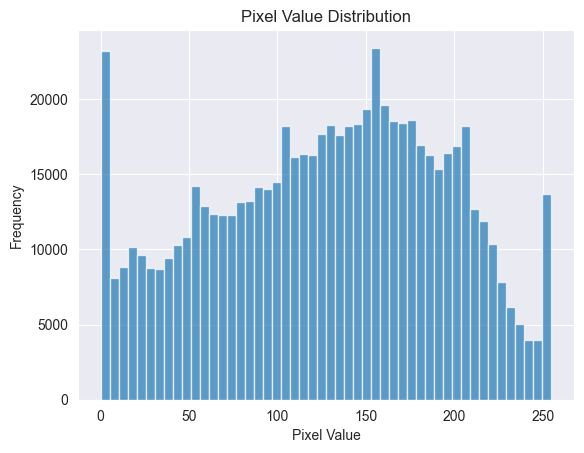

In [8]:
# Sample a few images and analyze pixel distributions
sample_images = []
sample_labels = []

for i, (image, label) in enumerate(image_datasets['train']):
    if i < 100:  # Sample first 100 images
        sample_images.append(np.array(image))
        sample_labels.append(label)
    else:
        break

# Analyze pixel value ranges
pixel_values = np.concatenate([img.flatten() for img in sample_images])
print(f"Pixel value range: [{pixel_values.min()}, {pixel_values.max()}]")
print(f"Mean: {pixel_values.mean():.2f}, Std: {pixel_values.std():.2f}")

# Plot distribution
plt.hist(pixel_values, bins=50, alpha=0.7)
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')


plt.show()

Standard deviation of the pixel value is more than 50 (66.06), which means that the images should have sufficient contrast to be interpreted.

In [9]:
# Display sample images from each class
from collections import defaultdict
def plot_class_samples_optimized(dataset, samples_per_class=5, max_classes=None, 
                               figsize_per_image=(2, 2), random_sampling=True, 
                               seed=327, show_stats=True):
    """
    Optimized function to display sample images from each class.
    
    Args:
        dataset: PyTorch dataset
        samples_per_class: Number of samples to show per class
        max_classes: Limit number of classes to show (None = all)
        figsize_per_image: Size of each subplot
        random_sampling: If True, randomly sample images; if False, take first N
        seed: Random seed for reproducible sampling
        show_stats: Whether to show pixel statistics
    """
    
    if random_sampling:
        random.seed(seed)
        np.random.seed(seed)
    
    # Efficient sample collection using defaultdict
    class_samples = defaultdict(list)
    class_names = getattr(dataset, 'classes', None)
    
    # Early stopping when we have enough samples
    samples_needed = samples_per_class
    if max_classes:
        max_samples_total = max_classes * samples_per_class
    else:
        max_samples_total = float('inf')
    
    total_collected = 0
    
    # Collect samples efficiently
    for i, (image, label) in enumerate(dataset):
        if total_collected >= max_samples_total:
            break
            
        # Get class name
        if class_names:
            label_name = class_names[label]
        else:
            label_name = f"Class_{label}"
        
        # Skip if we have enough samples for this class
        if len(class_samples[label_name]) >= samples_per_class:
            continue
            
        class_samples[label_name].append((np.array(image), i))  # Store image and index
        total_collected += 1
        
        # Early break if we have samples for max_classes
        if max_classes and len(class_samples) >= max_classes:
            if all(len(samples) >= samples_per_class for samples in class_samples.values()):
                break
    
    # Random sampling if requested
    if random_sampling:
        for class_name in class_samples:
            if len(class_samples[class_name]) > samples_per_class:
                class_samples[class_name] = random.sample(
                    class_samples[class_name], samples_per_class
                )
    
    # Sort classes for consistent display
    sorted_classes = sorted(class_samples.keys())
    if max_classes:
        sorted_classes = sorted_classes[:max_classes]
    
    n_classes = len(sorted_classes)
    n_samples = min(samples_per_class, 
                   max(len(class_samples[cls]) for cls in sorted_classes))
    
    # Create optimized subplot layout
    fig_width = figsize_per_image[0] * n_samples
    fig_height = figsize_per_image[1] * n_classes
    
    fig, axes = plt.subplots(n_classes, n_samples, 
                            figsize=(fig_width, fig_height),
                            squeeze=False)  # Always return 2D array
    
    # Plot samples with enhanced information
    for i, class_name in enumerate(sorted_classes):
        samples = class_samples[class_name]
        
        for j in range(n_samples):
            ax = axes[i, j]
            
            if j < len(samples):
                img, img_idx = samples[j]
                
                # Handle different image formats
                if len(img.shape) == 3 and img.shape[2] == 3:
                    # RGB image
                    display_img = img
                elif len(img.shape) == 3 and img.shape[2] == 1:
                    # Grayscale with channel dim
                    display_img = img.squeeze()
                else:
                    # Already grayscale
                    display_img = img
                
                ax.imshow(display_img, cmap='gray' if len(display_img.shape) == 2 else None)
                
                # Enhanced titles with statistics
                if show_stats and j == 0:
                    pixel_mean = img.mean()
                    pixel_std = img.std()
                    title = f'{class_name}\n(μ={pixel_mean:.1f}, σ={pixel_std:.1f})'
                elif j == 0:
                    title = class_name
                else:
                    title = f'#{img_idx}' if random_sampling else ''
                
                ax.set_title(title, fontsize=8, pad=2)
            else:
                # Empty subplot if not enough samples
                ax.axis('off')
                ax.text(0.5, 0.5, 'No sample', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=8, alpha=0.5)
                continue
            
            ax.axis('off')
    
    plt.tight_layout(pad=0.5)
    
    # Print summary statistics
    print(f"\nSample Inspection Summary:")
    print(f"Classes shown: {len(sorted_classes)}")
    print(f"Samples per class: {n_samples}")
    print(f"Total images displayed: {sum(len(class_samples[cls]) for cls in sorted_classes)}")
    
    if max_classes and len(class_samples) > max_classes:
        print(f"Note: Limited to first {max_classes} classes (total available: {len(class_samples)})")
    
    plt.show()


Sample Inspection Summary:
Classes shown: 7
Samples per class: 4
Total images displayed: 28


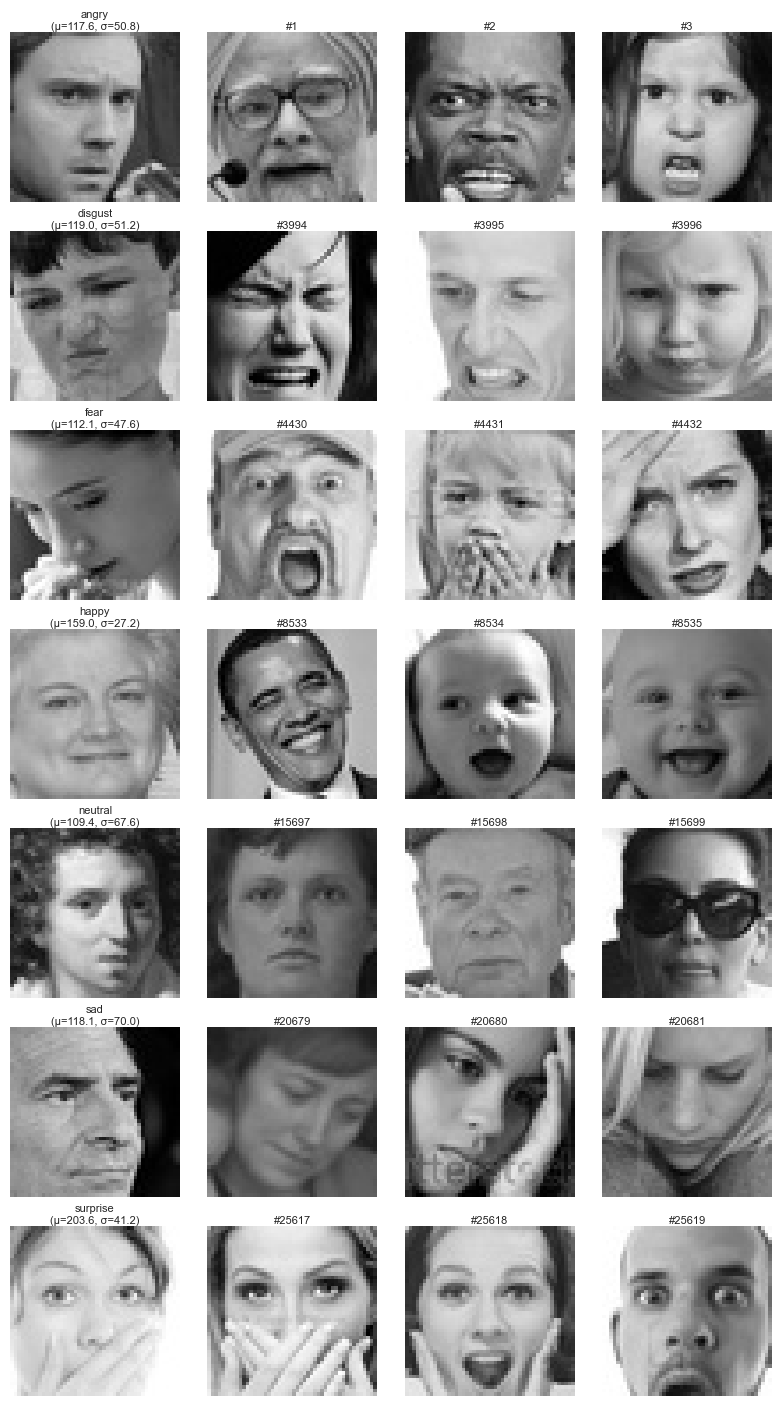

In [10]:
plot_class_samples_optimized(image_datasets['train'], 
                           samples_per_class=4, 
                           max_classes=len(image_datasets['train'].classes))

In [11]:
# Check for potential issues
def data_quality_check(dataset, sample_size=None):
    issues = {
        'corrupted_images': 0,
        'extreme_brightness': 0,
        'extreme_darkness': 0,
        'low_contrast': 0
    }
    corrupted_indices = {
        'corrupted_images': [],
        'extreme_brightness': [],
        'extreme_darkness': [],
        'low_contrast': []
    }

    # Reasonable thresholds for 8-bit images (0-255)
    BRIGHTNESS_HIGH = 0.9
    BRIGHTNESS_LOW = 0.05
    CONTRAST_LOW = 0.01

    total_samples = len(dataset) if sample_size is None else min(sample_size, len(dataset))
    print(f"Running data quality check on {total_samples} samples...")

    for i in tqdm(range(total_samples), desc='Checking images'):
        try:
            image, label = dataset[i]
            img_array = np.array(image)
            if img_array.size == 0:
                issues['corrupted_images'] += 1
                corrupted_indices['corrupted_images'].append(i)
                continue

            mean_brightness = img_array.mean()
            contrast = img_array.std()

            if mean_brightness > BRIGHTNESS_HIGH:
                issues['extreme_brightness'] += 1
                corrupted_indices['extreme_brightness'].append(i)
            elif mean_brightness < BRIGHTNESS_LOW:
                issues['extreme_darkness'] += 1
                corrupted_indices['extreme_darkness'].append(i)

            if contrast < CONTRAST_LOW:
                issues['low_contrast'] += 1
                corrupted_indices['low_contrast'].append(i)

        except Exception:
            issues['corrupted_images'] += 1
            corrupted_indices['corrupted_images'].append(i)

    print("Data Quality Report:")
    for issue, count in issues.items():
        percentage = (count / total_samples) * 100
        print(f"{issue}: {count} ({percentage:.1f}%)")

    all_corrupted_indices = set()
    for indices_list in corrupted_indices.values():
        all_corrupted_indices.update(indices_list)

    return {
        'issues_summary': issues,
        'corrupted_indices': corrupted_indices,
        'all_corrupted_indices': sorted(list(all_corrupted_indices)),
        'total_samples_checked': total_samples
    }

results = data_quality_check(image_datasets['train'], sample_size=1000)


Running data quality check on 1000 samples...


Checking images: 100%|██████████| 1000/1000 [00:06<00:00, 155.36it/s]

Data Quality Report:
corrupted_images: 0 (0.0%)
extreme_brightness: 996 (99.6%)
extreme_darkness: 4 (0.4%)
low_contrast: 4 (0.4%)


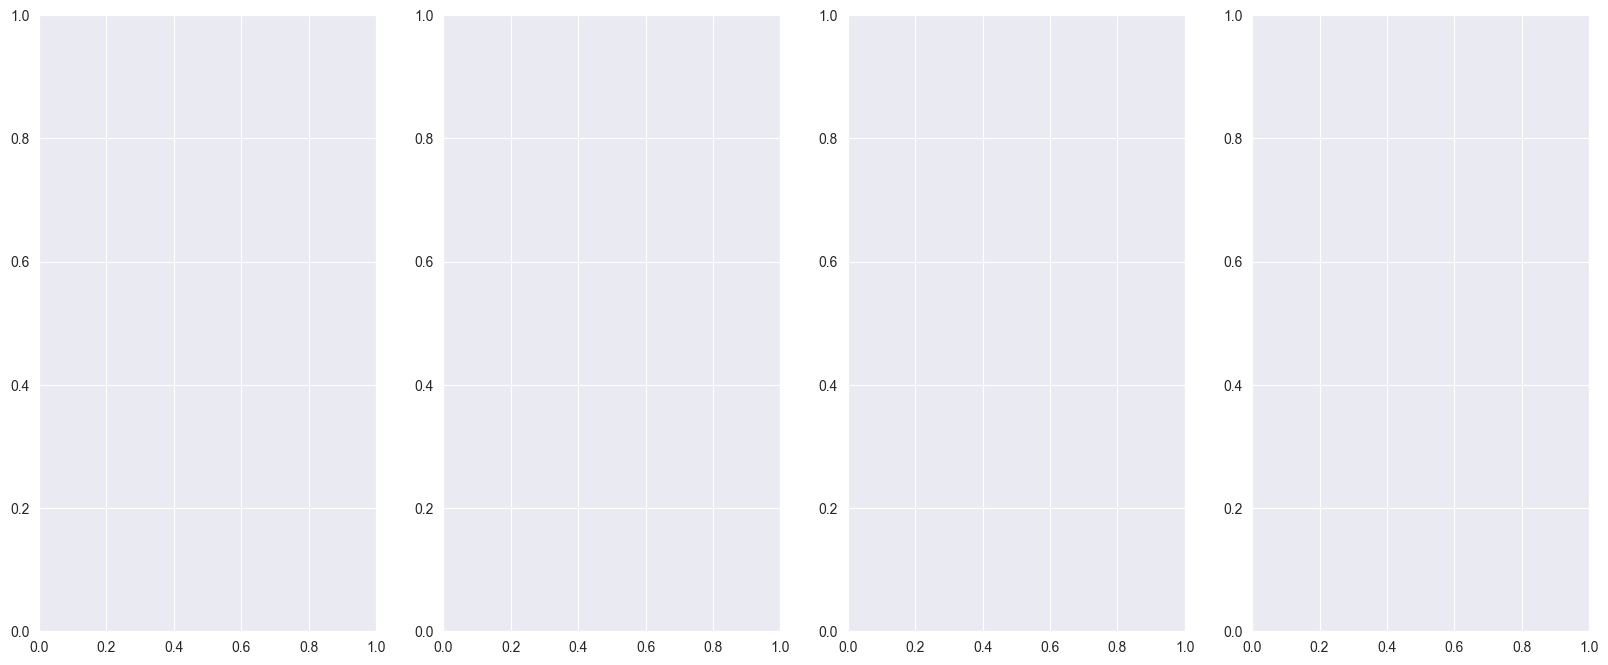

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

corr_imgs = [(image_datasets['train'][i][0], i) for i in results['corrupted_indices']['corrupted_images']]

for i, (ax, image) in enumerate(zip(axes, corr_imgs)):
    img = image[0]
    ax.imshow(img)
    ax.set_title(f'Image {image[-1]}')
    ax.axis('off')

In [13]:
transforms_dict = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  
        transforms.RandomAffine(10),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Resize((256,256)),
        transforms.ToTensor(),
    ]),
    'validation': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
}

In [22]:
corrupted_indices_train = data_quality_check(image_datasets['train'])
corrupted_indices_val = data_quality_check(image_datasets['val'])

Running data quality check on 28821 samples...


Checking images:   0%|          | 0/28821 [00:00<?, ?it/s]C:\Users\arnav\AppData\Local\Temp\ipykernel_17924\418266525.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img_array = np.array(image)
Checking images: 100%|██████████| 28821/28821 [00:37<00:00, 771.81it/s] 


Data Quality Report:
corrupted_images: 0 (0.0%)
extreme_brightness: 7 (0.0%)
extreme_darkness: 13 (0.0%)
low_contrast: 9 (0.0%)
Running data quality check on 7066 samples...


Checking images: 100%|██████████| 7066/7066 [00:05<00:00, 1362.06it/s]

Data Quality Report:
corrupted_images: 0 (0.0%)
extreme_brightness: 4 (0.1%)
extreme_darkness: 4 (0.1%)
low_contrast: 3 (0.0%)


In [ ]:
from torch.utils.data import Subset

def create_clean_dataset_indices(dataset, corrupted_indices):
    corrupted_set = set(corrupted_indices)
    clean_indices = [i for i in tqdm(range(len(dataset))) if i not in corrupted_set]
    return clean_indices

clean_train_indices = create_clean_dataset_indices(image_datasets['train'], corrupted_indices_train['all_corrupted_indices'])
clean_val_indices = create_clean_dataset_indices(image_datasets['val'], corrupted_indices_val['all_corrupted_indices'])


100%|██████████| 7066/7066 [00:00<00:00, 3747717.76it/s]


# Training

In [52]:
from torch.utils.data import Subset

# Update transforms to resize images to 48x48
transforms_dict['train'] = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomAffine(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])
transforms_dict['validation'] = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

# Re-apply transforms to the datasets
image_datasets['train'].transform = transforms_dict['train']
image_datasets['val'].transform = transforms_dict['validation']


clean_train_dataset = Subset(image_datasets['train'], clean_train_indices)
clean_val_dataset = Subset(image_datasets['val'], clean_val_indices)

In [43]:
clean_train_indices

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,


In [53]:
from torch.utils.data import DataLoader
import torch
BATCH_SIZE = 64

if len(clean_train_dataset) == 0 or len(clean_val_dataset) == 0:
	print("Warning: One of the datasets is empty!")
	print(f"clean_train_dataset size: {len(clean_train_dataset)}")
	print(f"clean_val_dataset size: {len(clean_val_dataset)}")
	train_iter = None
	test_iter = None
else:
	train_iter = DataLoader(clean_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
	test_iter = DataLoader(clean_val_dataset, batch_size=BATCH_SIZE)

class_names = image_datasets['train'].classes

dataset_sizes = {'train': len(clean_train_dataset), 'val': len(clean_val_dataset)}
dataloaders = {'train': train_iter, 'val': test_iter}

print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")
print(f"Training samples: {dataset_sizes['train']}")
print(f"Validation samples: {dataset_sizes['val']}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Training samples: 28801
Validation samples: 7058
Using device: cuda


In [45]:
for i in dataloaders['train']:
    print(i[-1][4])
    break

tensor(5)


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super(CNNModel, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(5, 5), stride=(1, 1), padding='same'),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            nn.Dropout(0.3)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), stride=(1, 1), padding='same'),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            nn.Dropout(0.3)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=512, kernel_size=(3, 3), stride=(1, 1), padding='same'),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            nn.Dropout(0.3)
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=(3, 3), stride=(1, 1), padding='same'),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            nn.Dropout(0.3)
        )

        self.fc_block = nn.Sequential(
            nn.Linear(512 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)

        x = x.view(x.size(0), -1)

        x = self.fc_block(x)
        return x

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CNNModel(num_classes=7).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

summary(model, input_size=(32, 1, 48, 48), device=str(device))  

Using device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [32, 7]                   --
├─Sequential: 1-1                        [32, 64, 24, 24]          --
│    └─Conv2d: 2-1                       [32, 64, 48, 48]          1,664
│    └─ReLU: 2-2                         [32, 64, 48, 48]          --
│    └─BatchNorm2d: 2-3                  [32, 64, 48, 48]          128
│    └─MaxPool2d: 2-4                    [32, 64, 24, 24]          --
│    └─Dropout: 2-5                      [32, 64, 24, 24]          --
├─Sequential: 1-2                        [32, 128, 12, 12]         --
│    └─Conv2d: 2-6                       [32, 128, 24, 24]         73,856
│    └─ReLU: 2-7                         [32, 128, 24, 24]         --
│    └─BatchNorm2d: 2-8                  [32, 128, 24, 24]         256
│    └─MaxPool2d: 2-9                    [32, 128, 12, 12]         --
│    └─Dropout: 2-10                     [32, 128, 12, 12]         --
├─Sequ

In [49]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.003,  
    weight_decay=0.0001,  
    betas=(0.9, 0.999),
    eps=1e-8  
)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, class_names):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'models/newmodel.pth')

    # Final metrics
    print("\nClassification Report (Validation):")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("Confusion Matrix (Validation):")
    print(confusion_matrix(all_labels, all_preds))

In [ ]:
for batch in dataloaders['train']:
    images, labels = batch
    print(f"Batch shape: {images.shape}")
    print(f"Individual image shape: {images[0].shape}")
    print(f"Number of images in batch: {images.size(0)}")
    print(f"Number of channels: {images.size(1)}")
    print(f"Image height: {images.size(2)}")
    print(f"Image width: {images.size(3)}")
    break  

Batch shape: torch.Size([64, 1, 48, 48])
Individual image shape: torch.Size([1, 48, 48])
Number of images in batch: 64
Number of channels: 1
Image height: 48
Image width: 48


In [57]:
num_epochs = 30  

train_and_validate(
	model,
	dataloaders['train'],
	dataloaders['val'],
	criterion,
	optimizer,
	num_epochs,
	device,
	class_names
)

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'models/newmodel.pth')

# Plottting Model Performance